# Diffusion Model (DDPM) - TensorFlow / Keras



Starting training...
Epoch 01/20 | Train MSE Loss: 0.30522
Epoch 02/20 | Train MSE Loss: 0.14515
Epoch 03/20 | Train MSE Loss: 0.12085
Epoch 04/20 | Train MSE Loss: 0.10743
Epoch 05/20 | Train MSE Loss: 0.09665
Epoch 06/20 | Train MSE Loss: 0.09114
Epoch 07/20 | Train MSE Loss: 0.08658
Epoch 08/20 | Train MSE Loss: 0.08325
Epoch 09/20 | Train MSE Loss: 0.08041
Epoch 10/20 | Train MSE Loss: 0.07786
Epoch 11/20 | Train MSE Loss: 0.07681
Epoch 12/20 | Train MSE Loss: 0.07482
Epoch 13/20 | Train MSE Loss: 0.07242
Epoch 14/20 | Train MSE Loss: 0.07132
Epoch 15/20 | Train MSE Loss: 0.07001
Epoch 16/20 | Train MSE Loss: 0.06783
Epoch 17/20 | Train MSE Loss: 0.06774
Epoch 18/20 | Train MSE Loss: 0.06721
Epoch 19/20 | Train MSE Loss: 0.06615
Epoch 20/20 | Train MSE Loss: 0.06606

Generating final samples...


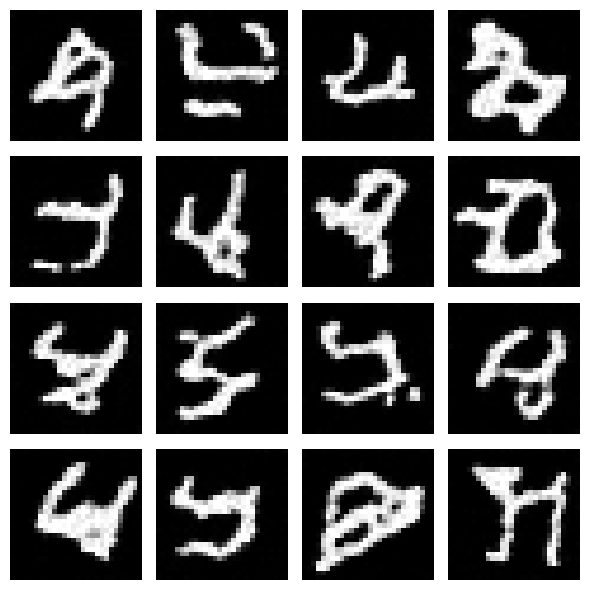

In [5]:
# =========================================
# 1. Imports
# =========================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Ensure reproducible results
tf.random.set_seed(42)
np.random.seed(42)

# =========================================
# 2. Load Dataset (MNIST)
# =========================================
(x_train, _), (_, _) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1)
x_train = x_train * 2.0 - 1.0  # Scale to [-1, 1]

batch_size = 128
dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(2048).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# =========================================
# 3. Diffusion Hyperparameters
# =========================================
timesteps = 200

# Linear variance schedule
betas = np.linspace(1e-4, 0.02, timesteps, dtype=np.float32)
alphas = 1.0 - betas
alphas_cumprod = np.cumprod(alphas)

sqrt_alphas_cumprod = tf.constant(np.sqrt(alphas_cumprod), dtype=tf.float32)
sqrt_one_minus_alphas_cumprod = tf.constant(np.sqrt(1.0 - alphas_cumprod), dtype=tf.float32)

# =========================================
# 4. Add Noise (Forward Process)
# =========================================
def add_noise(x, t):
    noise = tf.random.normal(shape=tf.shape(x))

    sqrt_alpha = tf.gather(sqrt_alphas_cumprod, t)[:, tf.newaxis, tf.newaxis, tf.newaxis]
    sqrt_one_minus = tf.gather(sqrt_one_minus_alphas_cumprod, t)[:, tf.newaxis, tf.newaxis, tf.newaxis]

    return sqrt_alpha * x + sqrt_one_minus * noise, noise

# =========================================
# 5. Model Architecture (Enhanced U-Net style)
# =========================================
def build_model():
    image_input = keras.Input(shape=(28, 28, 1), name="image_input")
    time_input = keras.Input(shape=(1,), dtype="int32", name="time_input")

    # Time Embedding Block
    t_emb = layers.Embedding(input_dim=timesteps, output_dim=64)(time_input)
    t_emb = layers.Dense(64, activation="swish")(t_emb)
    t_emb = layers.Dense(64)(t_emb)  # Shape: (batch_size, 1, 64)

    def time_injection(x, emb):
        # Dynamically project time embedding to match the channel dimension of x
        channels = x.shape[-1]
        emb_proj = layers.Dense(channels, activation="swish")(emb)
        # FIX: Expand dimensions to (batch_size, 1, 1, channels) for correct 4D broadcasting
        emb_proj = layers.Reshape((1, 1, channels))(emb_proj)
        return layers.Add()([x, emb_proj])

    # --- Downsampling Path ---
    # Block 1: 28x28x32
    x1 = layers.Conv2D(32, 3, padding="same", activation="swish")(image_input)
    x1 = time_injection(x1, t_emb)

    # Block 2: 14x14x64
    x2 = layers.Conv2D(64, 3, strides=2, padding="same", activation="swish")(x1)
    x2 = time_injection(x2, t_emb)

    # --- Bottleneck ---
    # Middle: 7x7x128
    x3 = layers.Conv2D(128, 3, strides=2, padding="same", activation="swish")(x2)
    x3 = layers.Conv2D(128, 3, padding="same", activation="swish")(x3)

    # --- Upsampling Path ---
    # Up 1: 14x14x64
    x_up1 = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="swish")(x3)
    x_up1 = layers.Concatenate()([x_up1, x2])  # Skip connection
    x_up1 = layers.Conv2D(64, 3, padding="same", activation="swish")(x_up1)

    # Up 2: 28x28x32
    x_up2 = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="swish")(x_up1)
    x_up2 = layers.Concatenate()([x_up2, x1])  # Skip connection
    x_up2 = layers.Conv2D(32, 3, padding="same", activation="swish")(x_up2)

    # Output Layer
    outputs = layers.Conv2D(1, 3, padding="same")(x_up2)

    return keras.Model([image_input, time_input], outputs)

model = build_model()
optimizer = keras.optimizers.Adam(learning_rate=2e-4)

# =========================================
# 6. Training Step
# =========================================
@tf.function
def train_step(x):
    batch_size = tf.shape(x)[0]
    t = tf.random.uniform((batch_size,), 0, timesteps, dtype=tf.int32)
    x_noisy, noise = add_noise(x, t)

    with tf.GradientTape() as tape:
        noise_pred = model([x_noisy, t], training=True)
        loss = tf.reduce_mean(tf.square(noise - noise_pred))

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

# =========================================
# 7. Training Loop
# =========================================
epochs = 20

print("Starting training...")
for epoch in range(epochs):
    epoch_losses = []
    for batch in dataset:
        loss = train_step(batch)
        epoch_losses.append(loss.numpy())  # .numpy() is safe here since we loop outside tf.function

    mean_loss = np.mean(epoch_losses)
    print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train MSE Loss: {mean_loss:.5f}")

# =========================================
# 8. Sampling (Reverse Diffusion Process)
# =========================================
def sample_images(num_images=16):
    x = tf.random.normal((num_images, 28, 28, 1))

    for t in reversed(range(timesteps)):
        t_batch = tf.fill((num_images,), t)
        noise_pred = model([x, t_batch], training=False)

        alpha = alphas[t]
        alpha_cumprod_t = alphas_cumprod[t]
        beta = betas[t]

        epsilon_factor = (1 - alpha) / np.sqrt(1 - alpha_cumprod_t)
        mean = (1 / np.sqrt(alpha)) * (x - epsilon_factor * noise_pred)

        if t > 0:
            noise = tf.random.normal(shape=tf.shape(x))
            x = mean + np.sqrt(beta) * noise
        else:
            x = mean

    return x

# =========================================
# 9. Visualization
# =========================================
print("\nGenerating final samples...")
generated = sample_images(16)
generated = (generated + 1) / 2.0
generated = np.clip(generated, 0.0, 1.0)

plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated[i, :, :, 0], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()